<a href="https://colab.research.google.com/github/daniellelooo/calidad-mineria-datos/blob/main/01_calidad_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notebook 1 — Calidad de Datos
## Práctica 4: Calidad y Minería de Datos en Python

**Curso:** Analítica de Datos
**Dataset:** Escuela de Talentos (Indeportes / IDER)
**Objetivo del notebook:**
1. Generar el perfilado de datos sobre el dataset **original**.
2. Diagnosticar las dimensiones de calidad de datos.
3. Implementar todos los pasos de limpieza y mejora.

**Atributos del dataset:**

| Atributo | Tipo | Descripción |
|---|---|---|
| `VIGENCIA` | Categórico (año) | Año del registro: 2022, 2023, 2024 |
| `Sector` | Categórico | OLIMPICO o PARALIMPICO |
| `Grupo_Etario` | Categórico | Rango etario del deportista |
| `Discapacidad` | Categórico | Tipo de discapacidad (o NO APLICA) |
| `Inversion_por_deportista` | Numérico | Inversión per cápita en COP |


## 1. Importación de librerías y carga del dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [ ]:
# Carga del archivo ARFF
data, meta = arff.loadarff('Escuela_Talento_limpio.arff')
df = pd.DataFrame(data)

# Decodificar bytes a strings (los ARFF cargan como bytes)
for col in df.select_dtypes(include=[object]).columns:
    df[col] = df[col].str.decode('utf-8')

print(f"Forma del dataset: {df.shape[0]} filas x {df.shape[1]} columnas")
df.head(10)

Forma del dataset: 7727 filas x 5 columnas


,VIGENCIA,Sector,Grupo_Etario,Discapacidad,Inversion_por_deportista
0,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
1,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
2,2022,OLIMPICO,Infancia 6-11,NO APLICA,3310519.10
3,2022,OLIMPICO,Infancia 6-11,NO APLICA,3310519.10
4,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
5,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
6,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
7,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
8,2022,OLIMPICO,Adolescencia 12-18,NO APLICA,3310519.10
9,2022,OLIMPICO,Infancia 6-11,NO APLICA,3310519.10


## 2. Perfilado automático de datos (datos originales)

Generamos el reporte HTML con `ydata-profiling`. Este perfilado se realiza sobre los **datos originales** (sin ninguna limpieza) tal como lo exige la práctica.

In [ ]:
# Instalar si es necesario:
!pip install ydata-profiling

from ydata_profiling import ProfileReport

profile = ProfileReport(
    df,
    title="Perfilado de Datos - Escuela de Talentos (Original)",
    explorative=True
)

# Guardar a HTML para entrega
profile.to_file("perfilado_original.html")
print("Reporte HTML generado: perfilado_original.html")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 400.8/400.8 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 22.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 40.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 24.58it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Reporte HTML generado: perfilado_original.html


In [ ]:
# Visualización embebida (opcional - útil para explorar dentro del notebook)
# profile.to_notebook_iframe()

## 3. Exploración inicial complementaria

In [ ]:
print("--- INFO ---")
df.info()
print()
print("--- ESTADISTICAS NUMERICAS ---")
print(df.describe())
print()
print("--- ESTADISTICAS CATEGORICAS ---")
print(df.describe(include='object'))

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7727 entries, 0 to 7726
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   VIGENCIA                  7727 non-null   object 
 1   Sector                    7727 non-null   object 
 2   Grupo_Etario              7727 non-null   object 
 3   Discapacidad              7727 non-null   object 
 4   Inversion_por_deportista  7727 non-null   float64
dtypes: float64(1), object(4)
memory usage: 302.0+ KB

--- ESTADISTICAS NUMERICAS ---
       Inversion_por_deportista
count                   7727.00
mean                 3855608.85
std                  1155680.06
min                  1872659.18
25%                  3310519.10
50%                  3886119.79
75%                  4213258.65
max                 20334474.61

--- ESTADISTICAS CATEGORICAS ---
       VIGENCIA    Sector        Grupo_Etario Discapacidad
count      7727      7727    

In [ ]:
# Distribucion de cada variable categorica
for col in ['VIGENCIA', 'Sector', 'Grupo_Etario', 'Discapacidad']:
    print(f"\n--- {col} ---")
    print(df[col].value_counts(dropna=False))


--- VIGENCIA ---
VIGENCIA
2022    2997
2023    2530
2024    2200
Name: count, dtype: int64

--- Sector ---
Sector
OLIMPICO       7357
PARALIMPICO     370
Name: count, dtype: int64

--- Grupo_Etario ---
Grupo_Etario
Adolescencia 12-18      4159
Infancia 6-11           3480
Juventud 19-26            53
Primera Infancia 0-5      18
Adultez 27-59             17
Name: count, dtype: int64

--- Discapacidad ---
Discapacidad
NO APLICA             7502
FISICA                  98
PARALISIS CEREBRAL      44
INTELECTUAL             39
VISUAL                  38
AUDITIVA                 6
Name: count, dtype: int64


In [ ]:
# Conteo de duplicados
n_dup = df.duplicated().sum()
n_unique = df.drop_duplicates().shape[0]
print(f"Filas totales:        {df.shape[0]}")
print(f"Filas unicas:         {n_unique}")
print(f"Filas duplicadas:     {n_dup}")
print(f"% de duplicacion:     {n_dup / df.shape[0] * 100:.2f}%")

Filas totales:        7727
Filas unicas:         91
Filas duplicadas:     7636
% de duplicacion:     98.82%


In [ ]:
# Tabla cruzada Sector vs Discapacidad para detectar redundancia
ct = pd.crosstab(df['Sector'], df['Discapacidad'], margins=True, margins_name='TOTAL')
print(ct)

Discapacidad  AUDITIVA  FISICA  INTELECTUAL  NO APLICA  PARALISIS CEREBRAL  \
Sector                                                                       
OLIMPICO             0       0            0       7357                   0   
PARALIMPICO          6      98           39        145                  44   
TOTAL                6      98           39       7502                  44   

Discapacidad  VISUAL  TOTAL  
Sector                       
OLIMPICO           0   7357  
PARALIMPICO       38    370  
TOTAL             38   7727  


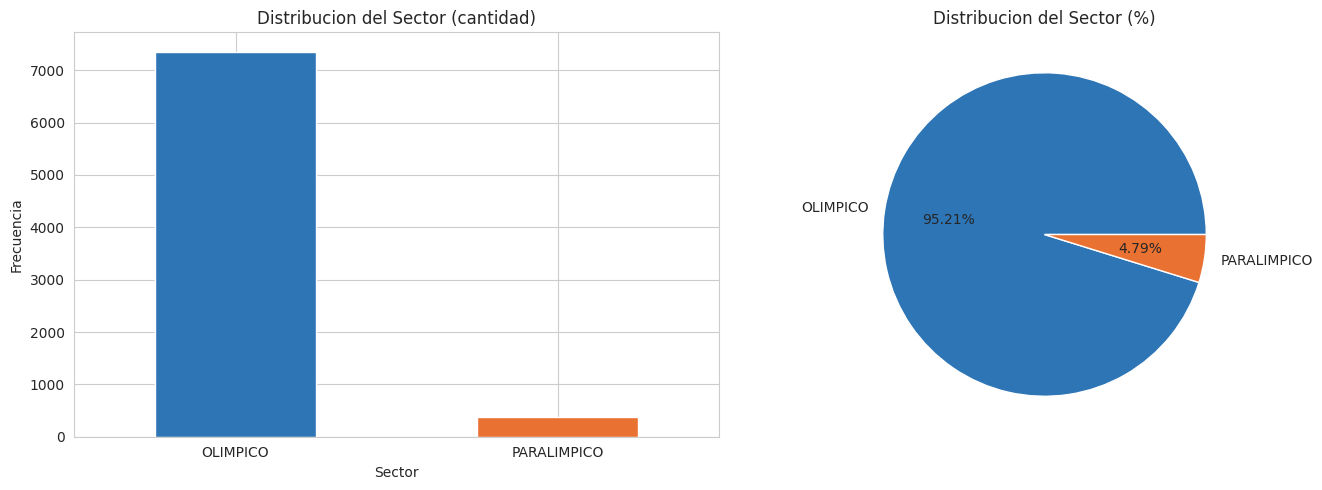


Desbalance fuerte: 95.21% de la clase mayoritaria.


In [ ]:
# Visualizacion: distribucion del target Sector
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['Sector'].value_counts().plot(kind='bar', ax=axes[0], color=['#2E75B6', '#E97132'])
axes[0].set_title('Distribucion del Sector (cantidad)')
axes[0].set_ylabel('Frecuencia')
axes[0].tick_params(axis='x', rotation=0)

df['Sector'].value_counts(normalize=True).plot(
    kind='pie', ax=axes[1], autopct='%1.2f%%', colors=['#2E75B6', '#E97132'])
axes[1].set_title('Distribucion del Sector (%)')
axes[1].set_ylabel('')

plt.tight_layout(); plt.show()
print(f"\nDesbalance fuerte: {df['Sector'].value_counts(normalize=True).max() * 100:.2f}% de la clase mayoritaria.")

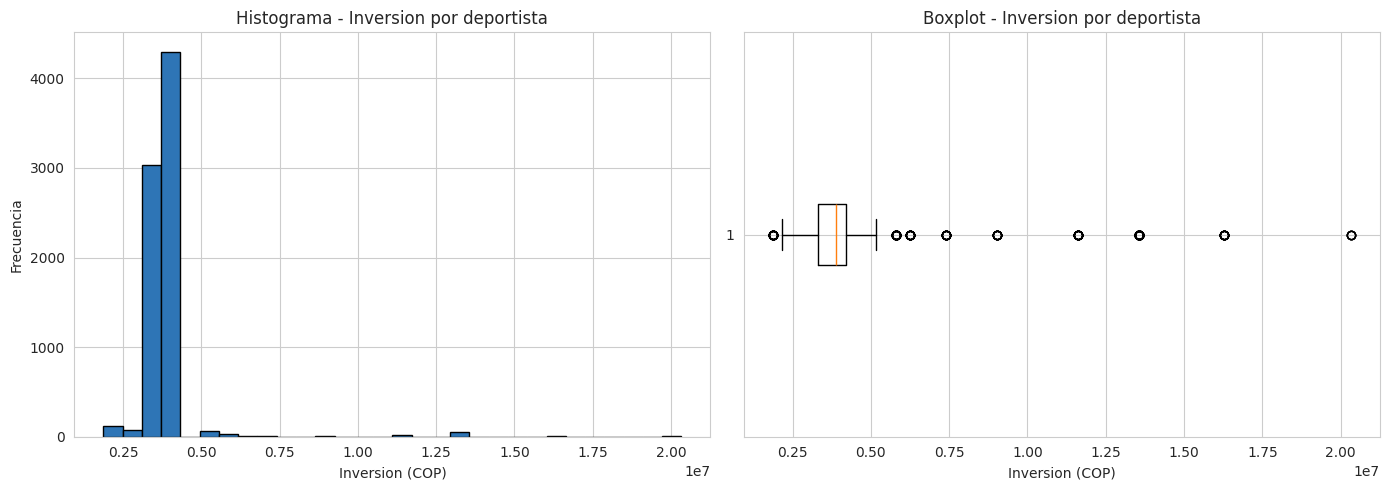

Valores unicos de Inversion_por_deportista: 21
Valores unicos:
[np.float64(1872659.18), np.float64(2160760.59), np.float64(2340823.97), np.float64(2553626.15), np.float64(2592912.71), np.float64(2808988.76), np.float64(3025064.82), np.float64(3281250.0), np.float64(3310519.1), np.float64(3511235.96), np.float64(3886119.79), np.float64(4213258.65), np.float64(5160151.32), np.float64(5809849.89), np.float64(6256761.42), np.float64(7394354.4), np.float64(9037544.27), np.float64(11619699.78), np.float64(13556316.41), np.float64(16267579.69), np.float64(20334474.61)]


In [ ]:
# Distribucion de Inversion_por_deportista
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(df['Inversion_por_deportista'], bins=30, color='#2E75B6', edgecolor='black')
axes[0].set_title('Histograma - Inversion por deportista')
axes[0].set_xlabel('Inversion (COP)'); axes[0].set_ylabel('Frecuencia')

axes[1].boxplot(df['Inversion_por_deportista'], vert=False)
axes[1].set_title('Boxplot - Inversion por deportista')
axes[1].set_xlabel('Inversion (COP)')

plt.tight_layout(); plt.show()

print(f"Valores unicos de Inversion_por_deportista: {df['Inversion_por_deportista'].nunique()}")
print("Valores unicos:")
print(sorted(df['Inversion_por_deportista'].unique()))

## 4. Diagnóstico de calidad de datos por dimensiones

Se evalúan las **seis dimensiones clásicas** de calidad de datos (DAMA-DMBOK / ISO 8000) sobre el dataset original:

### 4.1 Completitud (Completeness)
**¿Todos los registros tienen los valores requeridos?**

- **Resultado:** No hay valores nulos en ninguna columna (perfilado y `isnull().sum()` lo confirman).
- **Diagnóstico:** ✅ **Buena**. La dimensión completitud está al 100%.

### 4.2 Unicidad (Uniqueness)
**¿Existen registros duplicados que no deberían existir?**

- **Resultado:** 7.636 filas duplicadas de 7.727 (≈ 98,8%). Solo hay 91 combinaciones únicas.
- **Interpretación de negocio:** Cada fila representa **un deportista individual**. Como la inversión per cápita está calculada por categoría (vigencia + sector + grupo etario + discapacidad), miles de deportistas comparten el mismo perfil tabular.
- **Diagnóstico:** ⚠️ **A discutir según el caso de uso**.
  - Para análisis a nivel deportista (predicción individual) → los duplicados son legítimos y se conservan.
  - Para análisis a nivel categoría (agregados por grupo) → se deberían deduplicar.
- **Decisión de la práctica:** **Conservamos los duplicados** porque modelaremos a nivel deportista y los registros representan unidades reales.

### 4.3 Validez (Validity)
**¿Los valores cumplen las reglas/dominios definidos?**

- **Resultado:**
  - El esquema ARFF declara `Discapacidad ∈ {NO APLICA, FISICA, INTELECTUAL, VISUAL, PARALISIS CEREBRAL, AUDITIVA, NINGUNA}`, pero **NINGUNA nunca aparece en los datos**. Es una categoría declarada y no usada — semánticamente redundante con NO APLICA.
  - `VIGENCIA` está como cadena con comillas simples (formato ARFF) — puede convertirse a entero.
  - `Inversion_por_deportista` toma solo 21 valores distintos (es una variable derivada por fórmula presupuestal, no continua).
- **Diagnóstico:** ⚠️ **Validez parcial** — categorías declaradas no usadas; tipo de dato sub-óptimo en VIGENCIA.

### 4.4 Consistencia (Consistency)
**¿Los datos son coherentes entre columnas relacionadas?**

- **Resultado:** Existe **dependencia funcional perfecta** entre `Sector` y `Discapacidad`:
  - `Sector = OLIMPICO` ⟹ `Discapacidad = NO APLICA` (en el 100% de los casos).
  - `Sector = PARALIMPICO` ⟹ `Discapacidad ∈ {FISICA, INTELECTUAL, VISUAL, PARALISIS CEREBRAL, AUDITIVA}` (nunca NO APLICA).
- **Diagnóstico:** ⚠️ **Redundancia estructural**. No es una inconsistencia (ambas columnas se respetan entre sí), pero implica **fuga de información** (data leakage) si se usa Discapacidad como predictora de Sector. Se debe excluir Discapacidad como feature en el modelado.

### 4.5 Exactitud (Accuracy)
**¿Los datos representan la realidad?**

- **Resultado:** Sin un dataset de referencia (gold standard) no se puede medir exactitud absoluta. Sin embargo:
  - Los valores de inversión están en rangos razonables (1,87M – 20,3M COP), consistentes con presupuestos públicos en Colombia.
  - Las proporciones Olímpico/Paralímpico (≈ 95%/5%) son plausibles para una escuela de talentos.
- **Diagnóstico:** ✅ **Razonable** sin evidencia en contrario.

### 4.6 Oportunidad (Timeliness)
**¿Los datos están actualizados?**

- **Resultado:** Cubre 2022–2024 (registros vigentes y recientes).
- **Diagnóstico:** ✅ **Oportuno**.

---

### Resumen del diagnóstico

| Dimensión | Estado | Acción requerida |
|---|---|---|
| Completitud | ✅ OK | — |
| Unicidad | ⚠️ Contextual | Conservar (representan deportistas individuales) |
| Validez | ⚠️ Parcial | Mapear `NINGUNA → NO APLICA`; convertir `VIGENCIA` a int |
| Consistencia | ⚠️ Redundancia | Excluir `Discapacidad` como predictora de `Sector` (leakage) |
| Exactitud | ✅ Razonable | — |
| Oportunidad | ✅ OK | — |


## 5. Limpieza y mejora de los datos

Aplicamos los pasos derivados del diagnóstico:

1. Eliminar espacios en blanco residuales en strings.
2. Mapear `NINGUNA → NO APLICA` para resolver redundancia del esquema.
3. Convertir `VIGENCIA` a entero.
4. Conservar duplicados (representan deportistas).
5. Documentar la exclusión de `Discapacidad` como feature por leakage (se manejará en el notebook 2).

In [ ]:
df_clean = df.copy()

# Paso 1: strip de espacios en columnas categoricas
for col in df_clean.select_dtypes(include=[object]).columns:
    df_clean[col] = df_clean[col].str.strip()

# Paso 2: unificar NINGUNA con NO APLICA (sinonimos en el dominio)
df_clean['Discapacidad'] = df_clean['Discapacidad'].replace({'NINGUNA': 'NO APLICA'})

# Paso 3: convertir VIGENCIA a entero
df_clean['VIGENCIA'] = df_clean['VIGENCIA'].astype(int)

# Paso 4: NO eliminar duplicados (representan deportistas individuales)
print(f"Forma final: {df_clean.shape}")
print(f"Tipos:\n{df_clean.dtypes}")
print()
print("Verificacion de cambios:")
print(f"  Categorias de Discapacidad: {sorted(df_clean['Discapacidad'].unique())}")
print(f"  Tipo de VIGENCIA: {df_clean['VIGENCIA'].dtype}")
print(f"  Anios unicos: {sorted(df_clean['VIGENCIA'].unique())}")

Forma final: (7727, 5)
Tipos:
VIGENCIA                      int64
Sector                       object
Grupo_Etario                 object
Discapacidad                 object
Inversion_por_deportista    float64
dtype: object

Verificacion de cambios:
  Categorias de Discapacidad: ['AUDITIVA', 'FISICA', 'INTELECTUAL', 'NO APLICA', 'PARALISIS CEREBRAL', 'VISUAL']
  Tipo de VIGENCIA: int64
  Anios unicos: [np.int64(2022), np.int64(2023), np.int64(2024)]


In [ ]:
# Validacion final - resumen post-limpieza
print("=== RESUMEN POST-LIMPIEZA ===\n")
print(f"Filas: {df_clean.shape[0]} | Columnas: {df_clean.shape[1]}")
print(f"Nulos totales: {df_clean.isnull().sum().sum()}")
print(f"\nDistribucion del target Sector:")
print(df_clean['Sector'].value_counts())
print(f"\nProporciones:")
print(df_clean['Sector'].value_counts(normalize=True).round(4))

=== RESUMEN POST-LIMPIEZA ===

Filas: 7727 | Columnas: 5
Nulos totales: 0

Distribucion del target Sector:
Sector
OLIMPICO       7357
PARALIMPICO     370
Name: count, dtype: int64

Proporciones:
Sector
OLIMPICO      0.95
PARALIMPICO   0.05
Name: proportion, dtype: float64


In [ ]:
# Guardar dataset limpio para el notebook 2
df_clean.to_csv('escuela_talento_limpio.csv', index=False)
print("Dataset limpio guardado en: escuela_talento_limpio.csv")

Dataset limpio guardado en: escuela_talento_limpio.csv


## 6. Conclusiones del notebook de calidad

- El dataset **no tiene problemas de completitud**: 0 nulos.
- El **98,8 % de duplicación** es **aparente, no real**: cada fila representa un deportista individual y los perfiles tabulares se repiten naturalmente.
- Hay una **redundancia estructural perfecta** entre `Sector` y `Discapacidad`. En el modelo predictivo, `Discapacidad` se excluirá como feature para evitar data leakage.
- La categoría `NINGUNA` definida en el esquema ARFF nunca se usa y se unifica con `NO APLICA`.
- `VIGENCIA` se promueve a entero para mejor manejo en el modelado.
- El dataset limpio (`escuela_talento_limpio.csv`) se usa como entrada del notebook 2.